# Example usage of the MolJSON format
This notebook gives a short walkthrough of the MolJSON functions. Please see the `openai_moljson_example.ipynb` and `anthropic_moljson_example.ipynb` notebooks for examples of using MolJSON with the OpenAI and Anthropic APIs. 

In [1]:
import json
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw
from moljson import GetSchema, MolToJSON, MolFromJSON, CheckRoundTrip

## 1) Load schema
When using "structured output" mode with LLMs, you need to provide a JSON schema. ```schema = GetSchema()``` gets this JSON schema.

In [2]:
schema = GetSchema()
print(json.dumps(schema, indent=2))

{
  "type": "object",
  "additionalProperties": false,
  "required": [
    "atoms",
    "bonds",
    "charges",
    "aromatic_n_h"
  ],
  "properties": {
    "atoms": {
      "type": "array",
      "items": {
        "type": "object",
        "additionalProperties": false,
        "properties": {
          "id": {
            "type": "string",
            "description": "Unique atom id."
          },
          "element": {
            "type": "string",
            "enum": [
              "*",
              "H",
              "He",
              "Li",
              "Be",
              "B",
              "C",
              "N",
              "O",
              "F",
              "Ne",
              "Na",
              "Mg",
              "Al",
              "Si",
              "P",
              "S",
              "Cl",
              "Ar",
              "K",
              "Ca",
              "Sc",
              "Ti",
              "V",
              "Cr",
              "Mn",
            

## 2) Convert RDKit molecule to MolJSON
Use ```MolToJSON(mol)``` to convert an RDKit molecule to MolJSON. 
By default we use atom IDs of the element symbol followed by an integer, eg ```C1, C2, O1```. During preliminary assessments it was found that the ChatGPT web interface prefered to return JSONs in this form, so we implemented this as the default. You can override the atom IDs to be of the form ```a1, a2, a3,...``` by using ```MolToJSON(mol, atom_id_style="a")```. It is not clear what impact the atom ID style has on performance (if any). 

In [3]:
mol = Chem.MolFromSmiles('CCO')
moljson = MolToJSON(mol)
print(json.dumps(moljson, indent=2))

{
  "atoms": [
    {
      "id": "C1",
      "element": "C"
    },
    {
      "id": "C2",
      "element": "C"
    },
    {
      "id": "O1",
      "element": "O"
    }
  ],
  "bonds": [
    {
      "source": "C1",
      "target": "C2",
      "order": 1.0
    },
    {
      "source": "C2",
      "target": "O1",
      "order": 1.0
    }
  ]
}


## 3) MolJSON to RDKit molecule + round-trip pass check
To check completeness of the MolJSON representation you can perform a round trip check using ```CheckRoundTrip(mol)```. This takes an RDKit molecule, converts it to MolJSON, then converts it back to an RDKit molecule. The round trip passes if the canonicalised SMILES of the input and output molecules match. 

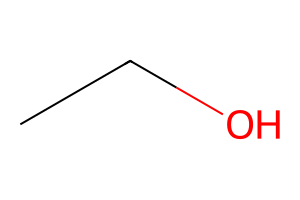

Round-trip passed: True
in_smiles:  CCO
out_smiles: CCO


In [4]:
mol2 = MolFromJSON(moljson)
display(Draw.MolToImage(mol2, size=(300, 200)))
ok, in_smi, out_smi, _ = CheckRoundTrip(mol)
print(f'Round-trip passed: {ok}')
print(f'in_smiles:  {in_smi}')
print(f'out_smiles: {out_smi}')

## 4) Round-trip checks

In [5]:
example_smiles = [
    'OC[s+]1cnc2[nH]ccc21',
    'CCCC(CC)O[s+]1cc(Cl)[nH]n(Cl)[nH]1',
    'COc1ccc(C(=O)C[n+]2[nH]n(N)c(=O)c2C(=O)NN=C(C)C)cc1',
    'Nc1c(I)c(Br)c[nH]c1=O',
    'Clc1cc(-c2nn[nH]n2)c2[nH]ccc2c1',
    'CC(Oc1cc(C(N)=O)[nH]c1C(=O)N(C)C(C)(C)C)c1ccccc1',
    'CCc1ccc(Br)[n+]([O-])c1',
    'CC(C)NC(C=[N+]1CCCC1C)C(C)(C)C',
    'C=C(C(=O)OCCCCCCCCCCCC)C(O)c1cc[n+]([O-])cc1',
    'CN1CC23COCC2(C1)C3',
    'Clc1nc(Cl)c2c(n1)nc1n2CCOC1',
    'CC(C)(C)OC(=O)N1CCC(n2cc(C#N)c3ncc(N)nc32)CC1',
    'C1NCC12CC1(CNC1)C2',
    'CC1CC2(C1)CN(Cc1ccccn1)C2',
    'O=C(CCl)N1CCC2(CCN(S(=O)(=O)c3ccc(Br)c(F)c3)C2)C1',
    'O=C1C=NSC1(c1ccccc1)c1ccccc1',
    'CCC(C)Cc1nnc(C)n1-c1sc(C)c(C)c1C(=N)c1ccc(Cl)cc1',
    'Fc1cccc2c1CNS2',
    'CCc1cc(C=O)c2c(c1)OCCO2',
    'CCCCC1c2ccc(C)cc2C(=O)N(S(C)(=O)=O)C1CC(=O)CC',
]

total = 0
passed = 0
failed = []

for smi in example_smiles:
    total += 1
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        failed.append((smi, 'smiles_parse_failed', ''))
        continue

    ok, in_smi, out_smi, _ = CheckRoundTrip(mol)
    if ok:
        passed += 1
    else:
        failed.append((smi, in_smi, out_smi))

print(f'Round-trip summary: {passed}/{total} passed')
if failed:
    print('Failures:')
    for smi, left, right in failed:
        print(f'- smiles={smi} in={left} out={right}')

Round-trip summary: 20/20 passed
